focused on ORGANIZATION and also continued factor analysis 

In [1]:
from IPython.display import display #deadass i think this does nothing but i dont wanna remove it 

from mlflow.models.signature import infer_signature

from src.features import feature_encoder, raw_data_loader

from src.modeling.fa_tuning import (
    build_best_factor_analysis_pipeline,
    tune_factor_analysis_rotation,
)

from src.plots import parallel_analysis

from src.utils.data_utils import convert_ahi

import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

import mlflow

import pandas as pd

import numpy as np

import json

import os


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["MLFLOW_EXPERIMENT_NAME"] = "2.3-jp-feature-engineering"

mlflow.set_tracking_uri("file:///Users/jack/Repos/apnea-predictor/mlruns")
mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME", "default_experiment"))

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/jack/Repos/apnea-predictor/mlruns/825373606965551241', creation_time=1776728062398, experiment_id='825373606965551241', last_update_time=1776728062398, lifecycle_stage='active', name='2.3-jp-feature-engineering', tags={}, workspace='default'>

In [3]:
df = raw_data_loader.load_and_clean_raw("..")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1880 entries, 0 to 1880
Columns: 409 entries, ('participants_age', 'modified_dem_0110', 'demographics') to ('apnea_hypopnea_index', 'ahi', 'output')
dtypes: Int64(8), boolean(1), datetime64[ns](19), float64(379), object(2)
memory usage: 5.9+ MB


In [4]:
df = feature_encoder.encode_features(df)

df = df.drop(columns=['ess_total_score', 'isi_total_score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1687 entries, 0 to 1686
Columns: 147 entries, age to dream_recall_frequency_rarely_or_never
dtypes: float64(136), int64(11)
memory usage: 1.9 MB


In [5]:
rotations = [
    "varimax",  # (orthogonal rotation)
    "promax",  # (oblique rotation)
    "oblimin",  # (oblique rotation)
    "oblimax",  # (orthogonal rotation)
    "quartimin",  # (oblique rotation)
    "quartimax",  # (orthogonal rotation)
    "equamax"  # (orthogonal rotation)
]


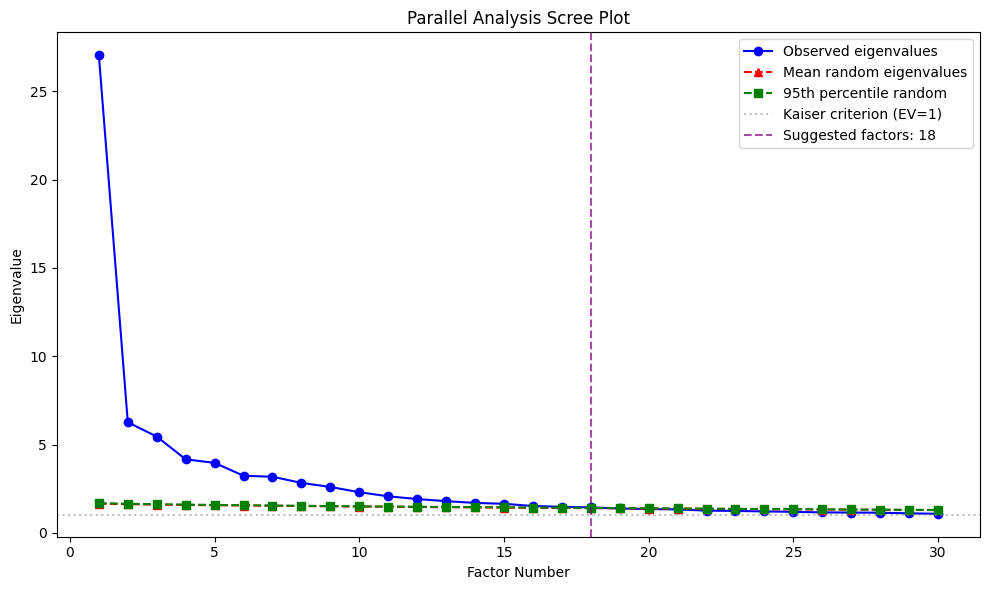


Parallel analysis suggests 18 factors


In [6]:
parallel_analysis(df.drop(columns=["ahi"]), n_iterations=1000)  # parallel analysis suggests 18 factors

In [7]:
BEST_PARAMS_PATH = "../data/interim/best_fa_xgb_params.json"

X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

rotations = [ # im pretty sure varimax is the best definitivley so maybe on reruns just remove this part from the cv
    "varimax",  # (orthogonal rotation)
    "promax",  # (oblique rotation)
    "oblimin",  # (oblique rotation)
    "oblimax",  # (orthogonal rotation)
    "quartimin",  # (oblique rotation)
    "quartimax",  # (orthogonal rotation)
    "equamax"  # (orthogonal rotation)
]

xgb_search_space = {
    "n_estimators": {"type": "int", "low": 100, "high": 500, "step": 50},
    "max_depth": {"type": "int", "low": 3, "high": 8},
    "min_child_weight": {"type": "int", "low": 1, "high": 10},
    "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
    "subsample": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "colsample_bytree": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "gamma": {"type": "float", "low": 0.0, "high": 5.0, "step": 0.5},
}


search_dataset = mlflow.data.from_pandas(
    pd.concat([X, y.rename("ahi")], axis=1),
    name="2.3-sleep-apnea-fa-xgb-search",
    targets="ahi",
)


BEST_PARAMS_FOUND = True # manual set casue this takes a while to run

if not BEST_PARAMS_FOUND:
    with mlflow.start_run(run_name="joint_fa_xgb_optuna_search"):

        mlflow.log_input(search_dataset, context="train")

        mlflow.set_tag("model_type", "factor-analysis-xgboost-pipeline")

        mlflow.set_tag("search_type", "joint_fa_xgb_optuna")

        mlflow.log_param("scoring", "roc_auc")

        mlflow.log_param("n_splits", 5)

        mlflow.log_param("n_trials", 40)

        mlflow.log_param("fixed_n_factors", 18)

        mlflow.log_param("candidate_rotations", ",".join(rotations))

        mlflow.log_dict(xgb_search_space, "xgb_search_space.json")

        tuning_result = tune_factor_analysis_rotation(
            X,
            y,
            rotations=rotations,
            n_factors=18,
            n_splits=5,
            n_trials=40,
            scoring="roc_auc",
            xgb_search_space=xgb_search_space,
            random_state=42,
        )

        best_fa_pipeline = build_best_factor_analysis_pipeline(tuning_result)

        best_fa_pipeline.fit(X, y)

        best_xgb_params = {
            key: value
            for key, value in tuning_result.best_params.items()
            if key not in {"rotation", "n_factors"}
        }

        mlflow.log_param("best_rotation", tuning_result.best_rotation)

        mlflow.log_param("best_n_factors", tuning_result.best_params.get("n_factors", 18))

        mlflow.log_params({f"best_{key}": value for key, value in best_xgb_params.items()})

        mlflow.log_metric("best_mean_cv_roc_auc", tuning_result.best_score)

        mlflow.log_metric("completed_trials", len(tuning_result.trial_results))

        mlflow.log_text(
            tuning_result.rotation_summary.to_csv(index=False),
            "rotation_summary.csv",
        )

        mlflow.log_text(
            tuning_result.trial_results.to_csv(index=False),
            "trial_results.csv",
        )

        signature = infer_signature(X, best_fa_pipeline.predict(X))

        mlflow.sklearn.log_model(
            best_fa_pipeline,
            name="best_fa_xgb_pipeline",
            signature=signature,
        )

        # Save best params to disk so future runs skip the search
        with open(BEST_PARAMS_PATH, "w") as f:
            json.dump(tuning_result.best_params, f, indent=2)

    print(f"Best rotation: {tuning_result.best_rotation}")

    print(f"Best n_factors: {tuning_result.best_params.get('n_factors', 18)}")

    print(f"Best mean CV ROC-AUC: {tuning_result.best_score:.4f}")

    print("Best XGBoost params:")

    print(best_xgb_params)

    display(tuning_result.rotation_summary)

    display(tuning_result.trial_results)


# Always load from disk so downstream cells work regardless of BEST_PARAMS_FOUND
from types import SimpleNamespace

with open(BEST_PARAMS_PATH) as f:
    _saved_params = json.load(f)

best_fa_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params=_saved_params,
        best_rotation=_saved_params.get("rotation"),
    )
)
best_xgb_params = {k: v for k, v in _saved_params.items() if k not in {"rotation", "n_factors"}}

print(f"Loaded best_rotation : {_saved_params.get('rotation')}")
print(f"Loaded best_n_factors: {_saved_params.get('n_factors', 18)}")
print(f"Loaded XGBoost params : {best_xgb_params}")


Loaded best_rotation : varimax
Loaded best_n_factors: 18
Loaded XGBoost params : {'n_estimators': 450, 'max_depth': 6, 'min_child_weight': 9, 'learning_rate': 0.016099070709256574, 'subsample': 0.6, 'colsample_bytree': 1.0, 'gamma': 5.0}


the cell above does hyperamater searching on the entire pipeline and lowkey i don't know
why is set it up this way but i mean i guess its something ill figure it out in the
future and perhaps just save a model for parameters and then mess with the datasets
the dataaset is much more important anyway

as i am running the brother above it seems like all the difference is quite marginal

Saving just in case it gets overrun
Best rotation: varimax
Best n_factors: 18
Best mean CV ROC-AUC: 0.5314
Best XGBoost params:
{'n_estimators': 450, 'max_depth': 6, 'min_child_weight': 9, 'learning_rate': 0.016099070709256574, 'subsample': 0.6, 'colsample_bytree': 1.0, 'gamma': 5.0}

In [8]:
mlflow.xgboost.autolog()
mlflow.sklearn.autolog()

In [9]:
from mlflow.artifacts import download_artifacts
from mlflow.tracking import MlflowClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np
import tempfile
import os
from xgboost import XGBClassifier

In [10]:

df = df.copy()
X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

fa_step = best_fa_pipeline.steps[0][1]      # factor analyzer
xgb_step = best_fa_pipeline.steps[-1][1]    # classifier (XGBClassifier)

# Use holdout data for explanations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_fa_pipeline.fit(X_train, y_train)

# Transform into factor space (what XGBoost actually sees)
X_bg = X_train.sample(min(200, len(X_train)), random_state=42)
X_eval = X_test.sample(min(500, len(X_test)), random_state=42)

X_bg_fa = fa_step.transform(X_bg)
X_eval_fa = fa_step.transform(X_eval)

fa_cols = [f"FA_{i+1}" for i in range(X_eval_fa.shape[1])]

# Build SHAP explainer on the XGB model
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_eval_fa)

# Handle binary/multiclass output shape differences
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

preds = best_fa_pipeline.predict(X_test)
proba = best_fa_pipeline.predict_proba(X_test)
if proba.shape[1] == 2:
    roc_auc = roc_auc_score(y_test, proba[:, 1])
else:
    roc_auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
accuracy = accuracy_score(y_test, preds)
class_report = classification_report(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

with mlflow.start_run(run_name="tuned_fa_xgb_shap_eval"):
    mlflow.log_param("pipeline", "tuned_fa_xgb")
    mlflow.log_param("rotation", best_xgb_params.get("rotation", "varimax"))
    mlflow.log_param("n_factors", 18)
    mlflow.log_params({f"xgb_{k}": v for k, v in best_xgb_params.items()})

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("accuracy", accuracy)

    # 1) SHAP summary (beeswarm)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_beeswarm.png")
    plt.close()

    # 2) SHAP summary (bar importance)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, plot_type="bar", show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_bar.png")
    plt.close()

    # 3) Force plot for one sample as HTML artifact
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if np.ndim(expected_value) > 0 and len(expected_value) > 1 else np.ravel(expected_value)[0]

    force = shap.force_plot(
        expected_value,
        shap_values_plot[0],
        X_eval_fa.iloc[0],
        feature_names=fa_cols,
        matplotlib=False,
    )

    with tempfile.TemporaryDirectory() as td:
        force_path = os.path.join(td, "force_plot_sample0.html")
        shap.save_html(force_path, force)
        mlflow.log_artifact(force_path, artifact_path="shap")

    mlflow.log_text(class_report, "classification_report.txt")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)


2026/04/21 17:08:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3ccc9c9026ee42fab1e6b5fa0436b8a5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/04/21 17:08:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/21 17:08:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/anaconda3/envs/py312_env/lib/pytho

ROC-AUC: 0.5320
Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


the hyperparameter selections end up only predicting 1 class -_-

In [11]:
factor_analyzer = best_fa_pipeline.steps[0][1]

factor_analyzer.get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_phys_function_fss       0.832786
fati_prevents_sustained_phys_func_fss        0.824393
fati_top_three_disabling_sympts_fss          0.819425
fati_causes_freq_probs_for_me_fss            0.815738
fati_interferes_with_responsibilities_fss    0.812848
fati_interferes_with_work_fam_social_fss     0.798713
i_am_easily_fati_fss                         0.783652
lower_motivation_when_fati_fss               0.586320
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
not_able_to_control_worrying_freq_gad     0.818536
worry_too_much_diff_things_freq_gad       0.781222
feeling_anxious_freq_gad                  0.728557
feel_bad_abt_yourself_freq_phq            0.699199
feel_as_if_awful_might_happen_freq_gad    0.687949
feel_depressed_freq_phq                   0.680994
trouble_relaxing_freq_gad                 0.638659
easily_annoyed_freq_gad                   0.565541
Name: Factor_2, dtype: float64


Top loadings for Factor_3:
ess_chance_of

In [12]:
non_tuned_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params={
            "rotation": "varimax",
            "n_factors": 18,
        },
        best_rotation="varimax",
    )
)   

In [13]:

df = df.copy()
X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

fa_step = non_tuned_pipeline.steps[0][1]      # factor analyzer
xgb_step = non_tuned_pipeline.steps[-1][1]    # classifier (XGBClassifier)

# Use holdout data for explanations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

non_tuned_pipeline.fit(X_train, y_train)

# Transform into factor space (what XGBoost actually sees)
X_bg = X_train.sample(min(200, len(X_train)), random_state=42)
X_eval = X_test.sample(min(500, len(X_test)), random_state=42)

X_bg_fa = fa_step.transform(X_bg)
X_eval_fa = fa_step.transform(X_eval)

fa_cols = [f"FA_{i+1}" for i in range(X_eval_fa.shape[1])]

# Build SHAP explainer on the XGB model
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_eval_fa)

# Handle binary/multiclass output shape differences
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

preds = non_tuned_pipeline.predict(X_test)
proba = non_tuned_pipeline.predict_proba(X_test)
if proba.shape[1] == 2:
    roc_auc = roc_auc_score(y_test, proba[:, 1])
else:
    roc_auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
accuracy = accuracy_score(y_test, preds)
class_report = classification_report(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

with mlflow.start_run(run_name="non_tuned_fa_xgb_shap_eval"):
    mlflow.log_param("pipeline", "non_tuned_fa_xgb")
    mlflow.log_param("rotation", "varimax")
    mlflow.log_param("n_factors", 18)

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("accuracy", accuracy)

    # 1) SHAP summary (beeswarm)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_beeswarm.png")
    plt.close()

    # 2) SHAP summary (bar importance)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, plot_type="bar", show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_bar.png")
    plt.close()

    # 3) Force plot for one sample as HTML artifact
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if np.ndim(expected_value) > 0 and len(expected_value) > 1 else np.ravel(expected_value)[0]

    force = shap.force_plot(
        expected_value,
        shap_values_plot[0],
        X_eval_fa.iloc[0],
        feature_names=fa_cols,
        matplotlib=False,
    )

    with tempfile.TemporaryDirectory() as td:
        force_path = os.path.join(td, "force_plot_sample0.html")
        shap.save_html(force_path, force)
        mlflow.log_artifact(force_path, artifact_path="shap")

    mlflow.log_text(class_report, "classification_report.txt")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)


2026/04/21 17:08:12 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9fef4a451d9a43a88e0c71c598e774ce', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/21 17:08:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

ROC-AUC: 0.5221
Accuracy: 0.6450
              precision    recall  f1-score   support

           0       0.43      0.14      0.21       115
           1       0.67      0.91      0.77       223

    accuracy                           0.64       338
   macro avg       0.55      0.52      0.49       338
weighted avg       0.59      0.64      0.58       338

[[ 16  99]
 [ 21 202]]


despite being also not very good the non-tuned model is a lot better by nature of 
being able to predict more than one class

most important features:
FA_1,
FA_3,
FA_2,
FA_10,
FA_5,
FA_8,

In [14]:
non_tuned_pipeline[0].get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_phys_function_fss       0.832786
fati_prevents_sustained_phys_func_fss        0.824393
fati_top_three_disabling_sympts_fss          0.819425
fati_causes_freq_probs_for_me_fss            0.815738
fati_interferes_with_responsibilities_fss    0.812848
fati_interferes_with_work_fam_social_fss     0.798713
i_am_easily_fati_fss                         0.783652
lower_motivation_when_fati_fss               0.586320
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
not_able_to_control_worrying_freq_gad     0.818536
worry_too_much_diff_things_freq_gad       0.781222
feeling_anxious_freq_gad                  0.728557
feel_bad_abt_yourself_freq_phq            0.699199
feel_as_if_awful_might_happen_freq_gad    0.687949
feel_depressed_freq_phq                   0.680994
trouble_relaxing_freq_gad                 0.638659
easily_annoyed_freq_gad                   0.565541
Name: Factor_2, dtype: float64


Top loadings for Factor_3:
ess_chance_of

Top loadings for Factor_1:\
\
fati_interferes_with_phys_function_fss       0.832786\
fati_prevents_sustained_phys_func_fss        0.824393\
fati_top_three_disabling_sympts_fss          0.819425\
fati_causes_freq_probs_for_me_fss            0.815738\
fati_interferes_with_responsibilities_fss    0.812848\
fati_interferes_with_work_fam_social_fss     0.798713\
i_am_easily_fati_fss                         0.783652\
lower_motivation_when_fati_fss               0.586320\
Name: Factor_1, dtype: float64\
\
\
Top loadings for Factor_3:\
\
ess_chance_of_dozing_inactive_public                                      0.696736\
ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic    0.687985\
map_index_3_excessive_daytime_sleepiness_                                 0.657424\
ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol          0.656338\
ess_chance_of_dozing_sitting_and_talking_to_someone                       0.613317\
difficulty_operating_motor_vehicles_for_short_distances_fosq              0.609417\
ess_chance_of_dozing_car_passenger_hr                                     0.598727\
fall_asleep_driving_map                                                   0.598459\
Name: Factor_3, dtype: float64\
\
\
Top loadings for Factor_2:\
not_able_to_control_worrying_freq_gad     0.818536\
worry_too_much_diff_things_freq_gad       0.781222\
feeling_anxious_freq_gad                  0.728557\
feel_bad_abt_yourself_freq_phq            0.699199\
feel_as_if_awful_might_happen_freq_gad    0.687949\
feel_depressed_freq_phq                   0.680994\
trouble_relaxing_freq_gad                 0.638659\
easily_annoyed_freq_gad                   0.565541\
Name: Factor_2, dtype: float64\
\
\
Top loadings for Factor_10:\
difficulty_staying_asleep_isq                                    0.761898\
multiple_awakenings_isq                                          0.759901\
feel_sleep_not_sound_isq                                         0.738108\
feel_sleep_unrefreshing_isq                                      0.663080\
sleep_made_you_fatigued_isq                                      0.352356\
frequent_wakenings_map                                           0.224237\
how_noticeable_is_sleep_problem_impacting_quality_of_life_isi    0.219436\
diff_staying_asleep_isi                                          0.209770\
Name: Factor_10, dtype: float64\
\
\
Top loadings for Factor_5:\
sleep_affected_other_important_parts_of_life_isq    0.662083\
sleep_affected_your_social_life_isq                 0.661912\
sleep_caused_trouble_concentrating_isq              0.642619\
sleep_affected_work_isq                             0.627544\
sleep_made_you_irritable_isq                        0.595189\
sleep_made_you_fatigued_isq                         0.577808\
how_sleepy_do_you_feel_during_the_day_isq           0.525536\
feel_sleep_unrefreshing_isq                         0.376469\
Name: Factor_5, dtype: float64\
\
\
Top loadings for Factor_8:\
family_history_of_depression_mdhx                         0.658898\
family_history_of_psychiatric_treatment_mdhx              0.655571\
family_history_of_anxiety_mdhx                            0.606763\
family_history_of_other_psychiatric_illness_mdhx          0.473401\
psychiatric_or_mental_health_problem_mdhx                 0.359879\
family_history_of_fibromyalgia_or_chronic_fatigue_mdhx    0.354823\
family_history_of_insomnia_mdhx                           0.335192\
family_history_of_restless_leg_syndrome_mdhx              0.298959\
Name: Factor_8, dtype: float64\

In [15]:
# create dummy model
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")

with mlflow.start_run(run_name="dummy_classifier_eval"):

    dummy_preds = dummy_classifier.fit(X_train, y_train).predict(X_test)

    accuracy = accuracy_score(y_test, dummy_preds)
    class_report = classification_report(y_test, dummy_preds)
    conf_matrix = confusion_matrix(y_test, dummy_preds)

    mlflow.log_param("model", "dummy_classifier")
    mlflow.log_param("strategy", "most_frequent")

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_text(class_report, "classification_report.txt")
    mlflow.log_text(str(conf_matrix), "confusion_matrix.txt")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)

2026/04/21 17:08:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/21 17:08:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because

Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

model still worse than dummy -_- bruh

In [16]:
## SMOTE ADDED RAAA
from src.features.transformers import Factor_Analyzer_Transformer
from imblearn.over_sampling import SMOTE

df = df.copy()

X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)

smote_fa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)

X_transformed = smote_fa.fit_transform(X_train)

X_resampled, y_resampled = smote.fit_resample(X_transformed, y_train)


smote_xgb = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    random_state=42
)

with mlflow.start_run(run_name="smote_fa_xgb_eval"):
    smote_xgb.fit(X_resampled, y_resampled)
    smote_preds = smote_xgb.predict(smote_fa.transform(X_test))
    smote_proba = smote_xgb.predict_proba(smote_fa.transform(X_test))

    if smote_proba.shape[1] == 2:
        smote_roc_auc = roc_auc_score(y_test, smote_proba[:, 1])
    else:
        smote_roc_auc = roc_auc_score(y_test, smote_proba, multi_class="ovr", average="macro")
    smote_accuracy = accuracy_score(y_test, smote_preds)
    smote_class_report = classification_report(y_test, smote_preds)
    smote_conf_matrix = confusion_matrix(y_test, smote_preds)

    mlflow.log_param("pipeline", "smote_fa_xgb")
    mlflow.log_param("rotation", "varimax")
    mlflow.log_param("n_factors", 18)

    mlflow.log_metric("roc_auc", smote_roc_auc)
    mlflow.log_metric("accuracy", smote_accuracy)

    mlflow.log_text(smote_class_report, "classification_report.txt")

    mlflow.log_text(str(smote_conf_matrix), "confusion_matrix.txt")
    
print(f"ROC-AUC: {smote_roc_auc:.4f}")
print(f"Accuracy: {smote_accuracy:.4f}")
print(smote_class_report)
print(smote_conf_matrix)




2026/04/21 17:08:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '00c0468278c040f5b55d47fcff94f4b4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/21 17:08:22 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/04/21 17:08:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:08:22 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/21 17:08:24 WARNI

ROC-AUC: 0.5123
Accuracy: 0.5385
              precision    recall  f1-score   support

           0       0.36      0.48      0.41       115
           1       0.68      0.57      0.62       223

    accuracy                           0.54       338
   macro avg       0.52      0.52      0.52       338
weighted avg       0.57      0.54      0.55       338

[[ 55  60]
 [ 96 127]]


recall is a lot better but the overall accuracy is way worse and that is unfortunate i must think of ways to work around this

In [17]:
from __future__ import annotations

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

from src.features.transformers import Factor_Analyzer_Transformer
from src.utils.data_utils import convert_ahi

warnings.filterwarnings("ignore")

# ── reproducible split ────────────────────────────────────────────────────────
df_exp = df.copy()
X_all = df_exp.drop(columns=["ahi"])
y_all = convert_ahi(df_exp["ahi"])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos  # scale_pos_weight for XGBoost

print(f"Train class distribution  — 0: {neg}, 1: {pos}  (scale_pos_weight={spw:.2f})")
print(f"Test  class distribution  — 0: {(y_test==0).sum()}, 1: {(y_test==1).sum()}")

Train class distribution  — 0: 459, 1: 890  (scale_pos_weight=0.52)
Test  class distribution  — 0: 115, 1: 223


In [18]:

# ── evaluation helper ─────────────────────────────────────────────────────────
def evaluate(name: str, y_true, y_pred, y_proba, threshold: float = 0.5) -> dict:
    """Compute metrics, print a tidy summary, and return a result dict."""
    proba_pos = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    auc = roc_auc_score(y_true, proba_pos)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"\n{'─' * 58}")
    print(f"  {name}")
    print(f"{'─' * 58}")
    print(
        f"  ROC-AUC : {auc:.4f}  |  Accuracy : {acc:.4f}"
        f"  |  F1-macro : {f1m:.4f}  (thresh={threshold:.2f})"
    )
    print(classification_report(y_true, y_pred, target_names=["no_apnea", "apnea"]))
    return {
        "model": name,
        "roc_auc": round(auc, 4),
        "accuracy": round(acc, 4),
        "f1_macro": round(f1m, 4),
        "threshold": threshold,
    }


In [19]:

# ── run all strategies ────────────────────────────────────────────────────────
results = []
model_store = []  # parallel list: (model_obj, X_to_predict_on)

# 1. Raw XGBoost — no FA, no imbalance handling
raw_xgb = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
raw_xgb.fit(X_train, y_train)
model_store.append((raw_xgb, X_test))
results.append(evaluate("1. Raw XGBoost (no FA)", y_test, raw_xgb.predict(X_test), raw_xgb.predict_proba(X_test)))

# 2. XGBoost + scale_pos_weight — imbalance fix without resampling
spw_xgb = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")
spw_xgb.fit(X_train, y_train)
model_store.append((spw_xgb, X_test))
results.append(evaluate("2. XGBoost + scale_pos_weight (no FA)", y_test, spw_xgb.predict(X_test), spw_xgb.predict_proba(X_test)))

# 3. FA(18) + XGBoost + scale_pos_weight
fa18_pipe = Pipeline([
    ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
fa18_pipe.fit(X_train, y_train)
model_store.append((fa18_pipe, X_test))
results.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", y_test, fa18_pipe.predict(X_test), fa18_pipe.predict_proba(X_test)))

# 4. FA(6 top SHAP factors) + XGBoost + scale_pos_weight
fa6_pipe = Pipeline([
    ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=6)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
fa6_pipe.fit(X_train, y_train)
model_store.append((fa6_pipe, X_test))
results.append(evaluate("4. FA(6) + XGBoost + scale_pos_weight", y_test, fa6_pipe.predict(X_test), fa6_pipe.predict_proba(X_test)))

# 5. SMOTE + FA(18) + XGBoost  (existing baseline, re-run cleanly)
_smote_fa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
X_tr_fa18 = _smote_fa.fit_transform(X_train)
X_te_fa18 = _smote_fa.transform(X_test)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr_fa18, y_train)
smote_base_clf = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
smote_base_clf.fit(X_res, y_res)
model_store.append((smote_base_clf, X_te_fa18))
results.append(evaluate("5. SMOTE + FA(18) + XGBoost (baseline)", y_test, smote_base_clf.predict(X_te_fa18), smote_base_clf.predict_proba(X_te_fa18)))

# 6. BalancedRandomForest — handles imbalance natively, no FA
brf = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
brf.fit(X_train, y_train)
model_store.append((brf, X_test))
results.append(evaluate("6. BalancedRandomForest (no FA)", y_test, brf.predict(X_test), brf.predict_proba(X_test)))


2026/04/21 17:08:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '59af3dcb1a1240f0821f405f85296902', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/04/21 17:08:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:08:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e425e5baf3f5409cb0d6746c92c61a31', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow



──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5062  |  Accuracy : 0.6154  |  F1-macro : 0.4970  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.37      0.19      0.25       115
       apnea       0.67      0.83      0.74       223

    accuracy                           0.62       338
   macro avg       0.52      0.51      0.50       338
weighted avg       0.57      0.62      0.57       338



2026/04/21 17:08:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:08:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3418f8512ace4c4fab2758dc31d31349', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



──────────────────────────────────────────────────────────
  2. XGBoost + scale_pos_weight (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.4709  |  Accuracy : 0.5680  |  F1-macro : 0.4846  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.32      0.24      0.28       115
       apnea       0.65      0.74      0.69       223

    accuracy                           0.57       338
   macro avg       0.49      0.49      0.48       338
weighted avg       0.54      0.57      0.55       338



2026/04/21 17:08:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:08:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b33d9fda61974d1cb07b9e30aeea0b8f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



──────────────────────────────────────────────────────────
  3. FA(18) + XGBoost + scale_pos_weight
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5400  |  Accuracy : 0.5385  |  F1-macro : 0.5190  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.37      0.50      0.42       115
       apnea       0.68      0.56      0.62       223

    accuracy                           0.54       338
   macro avg       0.53      0.53      0.52       338
weighted avg       0.58      0.54      0.55       338



2026/04/21 17:08:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



──────────────────────────────────────────────────────────
  4. FA(6) + XGBoost + scale_pos_weight
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5156  |  Accuracy : 0.5355  |  F1-macro : 0.5128  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.36      0.47      0.41       115
       apnea       0.68      0.57      0.62       223

    accuracy                           0.54       338
   macro avg       0.52      0.52      0.51       338
weighted avg       0.57      0.54      0.55       338



2026/04/21 17:08:43 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '005d040e3e4a4105a65ad619f4fc8a7c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/21 17:08:43 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/04/21 17:08:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:08:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/21 17:08:45 WARNI


──────────────────────────────────────────────────────────
  5. SMOTE + FA(18) + XGBoost (baseline)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5123  |  Accuracy : 0.5385  |  F1-macro : 0.5165  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.36      0.48      0.41       115
       apnea       0.68      0.57      0.62       223

    accuracy                           0.54       338
   macro avg       0.52      0.52      0.52       338
weighted avg       0.57      0.54      0.55       338


──────────────────────────────────────────────────────────
  6. BalancedRandomForest (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.4980  |  Accuracy : 0.5799  |  F1-macro : 0.4958  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.34      0.25      0.29       115
       apnea       0.66      0.75      0.70       223

    accuracy                           0

In [20]:

# ── optimal threshold on best ROC-AUC model ──────────────────────────────────
interim_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
best_idx = interim_df.index[0]  # index into results / model_store
best_model_obj, best_X = model_store[interim_df.iloc[0].name]  # original list index

best_proba = best_model_obj.predict_proba(best_X)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
best_thresh = float(thresholds[(tpr - fpr).argmax()])
tuned_preds = (best_proba >= best_thresh).astype(int)

results.append(evaluate(
    f"7. {interim_df.iloc[0]['model'].split('. ', 1)[1]} + thresh={best_thresh:.2f}",
    y_test, tuned_preds, best_model_obj.predict_proba(best_X),
    threshold=best_thresh,
))

# ── mlflow — single comparison run ───────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
winner = results_df.iloc[0]

with mlflow.start_run(run_name="model_improvement_comparison"):
    mlflow.log_text(results_df.to_csv(index=False), "model_comparison.csv")
    mlflow.log_metric("best_roc_auc", winner["roc_auc"])
    mlflow.log_metric("best_accuracy", winner["accuracy"])
    mlflow.log_metric("best_f1_macro", winner["f1_macro"])
    mlflow.log_param("best_model", winner["model"])
    mlflow.log_param("best_threshold", winner["threshold"])

# ── summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 58)
print("  MODEL COMPARISON SUMMARY (sorted by ROC-AUC)")
print("=" * 58)
display(results_df)



──────────────────────────────────────────────────────────
  7. FA(18) + XGBoost + scale_pos_weight + thresh=0.77
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5062  |  Accuracy : 0.5592  |  F1-macro : 0.5294  (thresh=0.77)
              precision    recall  f1-score   support

    no_apnea       0.38      0.45      0.41       115
       apnea       0.69      0.61      0.65       223

    accuracy                           0.56       338
   macro avg       0.53      0.53      0.53       338
weighted avg       0.58      0.56      0.57       338


  MODEL COMPARISON SUMMARY (sorted by ROC-AUC)


,model,roc_auc,accuracy,f1_macro,threshold
0,3. FA(18) + XGBoost + scale_pos_weight,0.5400,0.5385,0.5190,0.500000
1,4. FA(6) + XGBoost + scale_pos_weight,0.5156,0.5355,0.5128,0.500000
2,5. SMOTE + FA(18) + XGBoost (baseline),0.5123,0.5385,0.5165,0.500000
3,1. Raw XGBoost (no FA),0.5062,0.6154,0.4970,0.500000
4,7. FA(18) + XGBoost + scale_pos_weight + thres...,0.5062,0.5592,0.5294,0.766551
5,6. BalancedRandomForest (no FA),0.4980,0.5799,0.4958,0.500000
6,2. XGBoost + scale_pos_weight (no FA),0.4709,0.5680,0.4846,0.500000


In [21]:

# ── AHI threshold sweep ───────────────────────────────────────────────────────
# Best model from comparison: FA(18) + XGB + scale_pos_weight
# Sweep thresholds to find where the questionnaire signal actually lives

THRESHOLDS = [5, 15, 30]  # none/any | mild→moderate | moderate→severe

df_sweep = df.copy()
X_sweep = df_sweep.drop(columns=["ahi"])
ahi_raw = df_sweep["ahi"]

thresh_rows = []

with mlflow.start_run(run_name="ahi_threshold_sweep"):
    for thresh in THRESHOLDS:
        y_t = convert_ahi(ahi_raw, threshold=thresh)
        pos_t = y_t.sum()
        neg_t = len(y_t) - pos_t
        prev = pos_t / len(y_t)

        Xtr, Xte, ytr, yte = train_test_split(
            X_sweep, y_t, test_size=0.2, random_state=42, stratify=y_t
        )

        spw_t = (ytr == 0).sum() / (ytr == 1).sum() if (ytr == 1).sum() > 0 else 1.0

        pipe_t = Pipeline([
            ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
            ("clf", XGBClassifier(
                n_estimators=250, max_depth=4, random_state=42,
                scale_pos_weight=spw_t, eval_metric="logloss",
            )),
        ])
        pipe_t.fit(Xtr, ytr)

        proba_t = pipe_t.predict_proba(Xte)[:, 1]
        preds_t = pipe_t.predict(Xte)

        auc = roc_auc_score(yte, proba_t)
        acc = accuracy_score(yte, preds_t)
        f1m = f1_score(yte, preds_t, average="macro")

        mlflow.log_metric(f"roc_auc_thresh{thresh}", round(auc, 4))
        mlflow.log_metric(f"accuracy_thresh{thresh}", round(acc, 4))
        mlflow.log_metric(f"f1_macro_thresh{thresh}", round(f1m, 4))
        mlflow.log_metric(f"prevalence_thresh{thresh}", round(prev, 4))

        thresh_rows.append({
            "ahi_threshold": thresh,
            "label": f"AHI≥{thresh}",
            "n_positive": int(pos_t),
            "n_negative": int(neg_t),
            "prevalence": round(prev, 3),
            "roc_auc": round(auc, 4),
            "accuracy": round(acc, 4),
            "f1_macro": round(f1m, 4),
        })

        print(f"\n{'─'*58}")
        print(f"  AHI threshold = {thresh}  (positive={pos_t}, prevalence={prev:.1%})")
        print(f"{'─'*58}")
        print(classification_report(yte, preds_t, target_names=["negative", "apnea"]))

thresh_df = pd.DataFrame(thresh_rows)
mlflow.log_text(thresh_df.to_csv(index=False), "ahi_threshold_sweep.csv")

print("\n" + "=" * 58)
print("  AHI THRESHOLD SWEEP SUMMARY (FA18 + XGB + scale_pos_weight)")
print("=" * 58)
display(thresh_df)


2026/04/21 17:08:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



──────────────────────────────────────────────────────────
  AHI threshold = 5  (positive=1113, prevalence=66.0%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.37      0.50      0.42       115
       apnea       0.68      0.56      0.62       223

    accuracy                           0.54       338
   macro avg       0.53      0.53      0.52       338
weighted avg       0.58      0.54      0.55       338



2026/04/21 17:08:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:08:59 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 9ea5069194714652ada66f16062ad949. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'clf__scale_pos_weight\' was already logged with value=\'0.5157303370786517\' for run ID=\'9ea5069194714652ada66f16062ad949\'. Attempted logging new value \'1.9262472885032538\'.")]')]



──────────────────────────────────────────────────────────
  AHI threshold = 15  (positive=577, prevalence=34.2%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.61      0.50      0.55       222
       apnea       0.28      0.38      0.32       116

    accuracy                           0.46       338
   macro avg       0.45      0.44      0.44       338
weighted avg       0.50      0.46      0.47       338



2026/04/21 17:09:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:09:05 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 9ea5069194714652ada66f16062ad949. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'clf__scale_pos_weight\' was already logged with value=\'0.5157303370786517\' for run ID=\'9ea5069194714652ada66f16062ad949\'. Attempted logging new value \'5.454545454545454\'.")]')]



──────────────────────────────────────────────────────────
  AHI threshold = 30  (positive=261, prevalence=15.5%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.84      0.62      0.71       286
       apnea       0.15      0.37      0.21        52

    accuracy                           0.58       338
   macro avg       0.50      0.49      0.46       338
weighted avg       0.74      0.58      0.64       338


  AHI THRESHOLD SWEEP SUMMARY (FA18 + XGB + scale_pos_weight)


,ahi_threshold,label,n_positive,n_negative,prevalence,roc_auc,accuracy,f1_macro
0,5,AHI≥5,1113,574,0.660,0.5400,0.5385,0.5190
1,15,AHI≥15,577,1110,0.342,0.4724,0.4586,0.4364
2,30,AHI≥30,261,1426,0.155,0.5320,0.5799,0.4624


In [22]:

# ── multiclass setup ──────────────────────────────────────────────────────────
# Labels: 0=none (<5), 1=mild (5–14), 2=moderate (15–29), 3=severe (≥30)
# Class names kept in label order for all reports

MC_BINS   = [0, 5, 15, 30, float("inf")]
MC_LABELS = [0, 1, 2, 3]
MC_NAMES  = ["none", "mild", "moderate", "severe"]

def make_multiclass_y(ahi_series: pd.Series) -> pd.Series:
    return pd.cut(
        ahi_series,
        bins=MC_BINS,
        labels=MC_LABELS,
        right=False,
    ).astype(int)

def evaluate_mc(name: str, y_true, y_pred, y_proba) -> dict:
    """Multiclass metrics: macro ROC-AUC (OvR), accuracy, macro F1."""
    auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n{'─'*58}")
    print(f"  {name}")
    print(f"{'─'*58}")
    print(f"  ROC-AUC(OvR/macro): {auc:.4f}  |  Acc: {acc:.4f}  |  F1-macro: {f1m:.4f}")
    print(classification_report(y_true, y_pred, target_names=MC_NAMES, zero_division=0))
    return {
        "model": name,
        "roc_auc_ovr": round(auc, 4),
        "accuracy": round(acc, 4),
        "f1_macro": round(f1m, 4),
    }

# ── build dataset ─────────────────────────────────────────────────────────────
df_mc   = df.copy()
X_mc    = df_mc.drop(columns=["ahi"])
y_mc    = make_multiclass_y(df_mc["ahi"])

print("Multiclass label distribution:")
print(y_mc.value_counts().sort_index().rename(index=dict(enumerate(MC_NAMES))))


Multiclass label distribution:
ahi
none        574
mild        536
moderate    316
severe      261
Name: count, dtype: int64


In [23]:

# ── multiclass model comparison ───────────────────────────────────────────────
from imblearn.over_sampling import SMOTE as _SMOTE

Xtr_mc, Xte_mc, ytr_mc, yte_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

mc_results  = []
mc_models   = []   # (fitted_model, X_for_predict)

# ── 1. Raw XGBoost (no FA, no imbalance handling) ────────────────────────────
m1 = XGBClassifier(
    n_estimators=250, max_depth=4, random_state=42,
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
)
m1.fit(Xtr_mc, ytr_mc)
mc_models.append((m1, Xte_mc))
mc_results.append(evaluate_mc("1. Raw XGBoost (no FA)", yte_mc, m1.predict(Xte_mc), m1.predict_proba(Xte_mc)))

# ── 2. FA(18) + XGBoost ──────────────────────────────────────────────────────
m2 = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(
        n_estimators=250, max_depth=4, random_state=42,
        objective="multi:softprob", num_class=4, eval_metric="mlogloss",
    )),
])
m2.fit(Xtr_mc, ytr_mc)
mc_models.append((m2, Xte_mc))
mc_results.append(evaluate_mc("2. FA(18) + XGBoost", yte_mc, m2.predict(Xte_mc), m2.predict_proba(Xte_mc)))

# ── 3. SMOTE + FA(18) + XGBoost ──────────────────────────────────────────────
_fa3 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr3 = _fa3.fit_transform(Xtr_mc)
Xte3 = _fa3.transform(Xte_mc)
Xr3, yr3 = _SMOTE(random_state=42).fit_resample(Xtr3, ytr_mc)
m3 = XGBClassifier(
    n_estimators=250, max_depth=4, random_state=42,
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
)
m3.fit(Xr3, yr3)
mc_models.append((m3, Xte3))
mc_results.append(evaluate_mc("3. SMOTE + FA(18) + XGBoost", yte_mc, m3.predict(Xte3), m3.predict_proba(Xte3)))

# ── 4. BalancedRandomForest (no FA) ──────────────────────────────────────────
m4 = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m4.fit(Xtr_mc, ytr_mc)
mc_models.append((m4, Xte_mc))
mc_results.append(evaluate_mc("4. BalancedRandomForest (no FA)", yte_mc, m4.predict(Xte_mc), m4.predict_proba(Xte_mc)))

# ── 5. Dummy baseline ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier as _Dummy
m5 = _Dummy(strategy="most_frequent")
m5.fit(Xtr_mc, ytr_mc)
mc_models.append((m5, Xte_mc))
mc_results.append(evaluate_mc("5. Dummy (most_frequent)", yte_mc, m5.predict(Xte_mc), m5.predict_proba(Xte_mc)))


2026/04/21 17:09:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5057  |  Acc: 0.3077  |  F1-macro: 0.2449
              precision    recall  f1-score   support

        none       0.34      0.43      0.38       115
        mild       0.36      0.41      0.38       108
    moderate       0.14      0.10      0.11        63
      severe       0.16      0.08      0.10        52

    accuracy                           0.31       338
   macro avg       0.25      0.25      0.24       338
weighted avg       0.28      0.31      0.29       338



2026/04/21 17:09:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



──────────────────────────────────────────────────────────
  2. FA(18) + XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5177  |  Acc: 0.3225  |  F1-macro: 0.2469
              precision    recall  f1-score   support

        none       0.39      0.46      0.42       115
        mild       0.34      0.44      0.39       108
    moderate       0.14      0.08      0.10        63
      severe       0.12      0.06      0.08        52

    accuracy                           0.32       338
   macro avg       0.25      0.26      0.25       338
weighted avg       0.29      0.32      0.30       338



2026/04/21 17:09:18 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/04/21 17:09:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:09:18 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/21 17:09:20 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/04/21 17:09:20 WARNING mlflow.sklearn: Failed t


──────────────────────────────────────────────────────────
  3. SMOTE + FA(18) + XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5298  |  Acc: 0.2544  |  F1-macro: 0.2517
              precision    recall  f1-score   support

        none       0.34      0.26      0.30       115
        mild       0.26      0.21      0.23       108
    moderate       0.23      0.25      0.24        63
      severe       0.18      0.33      0.23        52

    accuracy                           0.25       338
   macro avg       0.25      0.26      0.25       338
weighted avg       0.27      0.25      0.26       338



2026/04/21 17:09:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



──────────────────────────────────────────────────────────
  4. BalancedRandomForest (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.4886  |  Acc: 0.2604  |  F1-macro: 0.2061
              precision    recall  f1-score   support

        none       0.32      0.40      0.35       115
        mild       0.31      0.31      0.31       108
    moderate       0.11      0.08      0.09        63
      severe       0.08      0.06      0.07        52

    accuracy                           0.26       338
   macro avg       0.20      0.21      0.21       338
weighted avg       0.24      0.26      0.25       338



2026/04/21 17:09:28 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID 23372d82c48f4bc7b564deb8aff162f1. Failed operations: [MlflowException("Changing param values is not allowed. Param with key=\'random_state\' was already logged with value=\'42\' for run ID=\'23372d82c48f4bc7b564deb8aff162f1\'. Attempted logging new value \'None\'.")]')]



──────────────────────────────────────────────────────────
  5. Dummy (most_frequent)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5000  |  Acc: 0.3402  |  F1-macro: 0.1269
              precision    recall  f1-score   support

        none       0.34      1.00      0.51       115
        mild       0.00      0.00      0.00       108
    moderate       0.00      0.00      0.00        63
      severe       0.00      0.00      0.00        52

    accuracy                           0.34       338
   macro avg       0.09      0.25      0.13       338
weighted avg       0.12      0.34      0.17       338



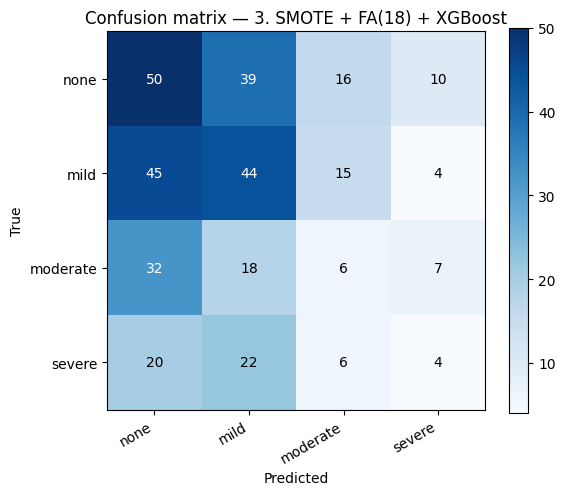


  MULTICLASS COMPARISON SUMMARY (sorted by ROC-AUC OvR)


,model,roc_auc_ovr,accuracy,f1_macro
0,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
1,2. FA(18) + XGBoost,0.5177,0.3225,0.2469
2,1. Raw XGBoost (no FA),0.5057,0.3077,0.2449
3,5. Dummy (most_frequent),0.5000,0.3402,0.1269
4,4. BalancedRandomForest (no FA),0.4886,0.2604,0.2061


In [24]:

# ── multiclass summary + confusion matrix + mlflow ────────────────────────────
mc_results_df = pd.DataFrame(mc_results).sort_values("roc_auc_ovr", ascending=False).reset_index(drop=True)
mc_winner     = mc_results_df.iloc[0]

# confusion matrix for the best model
best_mc_model, best_mc_X = mc_models[mc_results_df.iloc[0].name]
cm_mc = confusion_matrix(yte_mc, best_mc_model.predict(best_mc_X))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_mc, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(MC_NAMES, rotation=30, ha="right")
ax.set_yticklabels(MC_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {mc_winner['model']}")
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm_mc[i, j], ha="center", va="center",
                color="white" if cm_mc[i, j] > cm_mc.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
mlflow.end_run()  # end previous run if still active

with mlflow.start_run(run_name="multiclass_ahi_comparison"):
    mlflow.log_metric("best_roc_auc_ovr", mc_winner["roc_auc_ovr"])
    mlflow.log_metric("best_accuracy",    mc_winner["accuracy"])
    mlflow.log_metric("best_f1_macro",    mc_winner["f1_macro"])
    mlflow.log_param("best_model",        mc_winner["model"])
    mlflow.log_param("label_scheme",      "none<5 / mild5-14 / moderate15-29 / severe≥30")
    mlflow.log_text(mc_results_df.to_csv(index=False), "multiclass_comparison.csv")
    mlflow.log_figure(fig, "multiclass_confusion_matrix.png")

plt.show()

print("\n" + "=" * 58)
print("  MULTICLASS COMPARISON SUMMARY (sorted by ROC-AUC OvR)")
print("=" * 58)
display(mc_results_df)


## Approach A — Binary at AHI≥15 (moderate+ apnea)

Clinically, moderate-to-severe OSA (AHI≥15) is the actionable threshold for treatment. The class balance is also better than AHI≥5. Testing whether this target gives cleaner signal.

In [25]:

# ── binary AHI≥15 dataset ─────────────────────────────────────────────────────
df_15 = df.copy()
X_15  = df_15.drop(columns=["ahi"])
y_15  = convert_ahi(df_15["ahi"], threshold=15)   # moderate-or-severe vs none/mild

Xtr15, Xte15, ytr15, yte15 = train_test_split(
    X_15, y_15, test_size=0.2, random_state=42, stratify=y_15
)

neg15, pos15 = (ytr15 == 0).sum(), (ytr15 == 1).sum()
spw15 = neg15 / pos15

print(f"AHI≥15  train  — 0 (none/mild): {neg15},  1 (mod+sev): {pos15}  "
      f"(prevalence={pos15/(neg15+pos15):.1%}, spw={spw15:.2f})")
print(f"AHI≥15  test   — 0: {(yte15==0).sum()},  1: {(yte15==1).sum()}")


AHI≥15  train  — 0 (none/mild): 888,  1 (mod+sev): 461  (prevalence=34.2%, spw=1.93)
AHI≥15  test   — 0: 222,  1: 116


In [26]:

import lightgbm as lgb

# ── model comparison at AHI≥15 ────────────────────────────────────────────────
res15 = []
store15 = []

# 1. Raw XGBoost
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("1. Raw XGBoost", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 2. XGBoost + scale_pos_weight
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                  scale_pos_weight=spw15, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("2. XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 3. FA(18) + XGBoost + scale_pos_weight
m = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                          scale_pos_weight=spw15, eval_metric="logloss")),
])
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 4. SMOTE + FA(18) + XGBoost
_fa_15 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr15_fa = _fa_15.fit_transform(Xtr15)
Xte15_fa = _fa_15.transform(Xte15)
Xr15, yr15 = SMOTE(random_state=42).fit_resample(Xtr15_fa, ytr15)
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xr15, yr15)
store15.append((m, Xte15_fa))
res15.append(evaluate("4. SMOTE + FA(18) + XGBoost", yte15, m.predict(Xte15_fa), m.predict_proba(Xte15_fa)))

# 5. BalancedRandomForest
m = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("5. BalancedRandomForest", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 6. LightGBM — is_unbalance handles class skew natively
m = lgb.LGBMClassifier(
    n_estimators=300, max_depth=4, random_state=42,
    is_unbalance=True, verbose=-1,
)
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("6. LightGBM (is_unbalance)", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# ── optimal threshold on best model ──────────────────────────────────────────
interim15 = pd.DataFrame(res15).sort_values("roc_auc", ascending=False).reset_index(drop=True)
best15_obj, best15_X = store15[interim15.iloc[0].name]
best15_proba = best15_obj.predict_proba(best15_X)[:, 1]
fpr15, tpr15, thresholds15 = roc_curve(yte15, best15_proba)
best15_thresh = float(thresholds15[(tpr15 - fpr15).argmax()])
res15.append(evaluate(
    f"7. {interim15.iloc[0]['model'].split('. ',1)[1]} + thresh={best15_thresh:.2f}",
    yte15, (best15_proba >= best15_thresh).astype(int),
    best15_obj.predict_proba(best15_X),
    threshold=best15_thresh,
))

# ── log to mlflow ─────────────────────────────────────────────────────────────
res15_df = pd.DataFrame(res15).sort_values("roc_auc", ascending=False).reset_index(drop=True)
winner15 = res15_df.iloc[0]

mlflow.end_run()
with mlflow.start_run(run_name="binary_ahi15_comparison"):
    mlflow.log_param("ahi_threshold", 15)
    mlflow.log_text(res15_df.to_csv(index=False), "binary_ahi15_comparison.csv")
    mlflow.log_metric("best_roc_auc", winner15["roc_auc"])
    mlflow.log_metric("best_accuracy", winner15["accuracy"])
    mlflow.log_metric("best_f1_macro", winner15["f1_macro"])
    mlflow.log_param("best_model", winner15["model"])

print("\n" + "=" * 58)
print("  AHI≥15 BINARY COMPARISON (sorted by ROC-AUC)")
print("=" * 58)
display(res15_df)


2026/04/21 17:09:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8085fc7ea43a46daa641530303d8bfe4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/04/21 17:09:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:09:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '374ac6c9f7ea499abfba66fadc6ae3bd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow



──────────────────────────────────────────────────────────
  1. Raw XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5451  |  Accuracy : 0.6006  |  F1-macro : 0.5010  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.66      0.80      0.72       222
       apnea       0.37      0.22      0.28       116

    accuracy                           0.60       338
   macro avg       0.51      0.51      0.50       338
weighted avg       0.56      0.60      0.57       338



2026/04/21 17:09:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:09:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '98127cf2a9924802990a53c87bf3ac7f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



──────────────────────────────────────────────────────────
  2. XGBoost + scale_pos_weight
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5410  |  Accuracy : 0.6036  |  F1-macro : 0.5296  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.68      0.76      0.72       222
       apnea       0.40      0.30      0.34       116

    accuracy                           0.60       338
   macro avg       0.54      0.53      0.53       338
weighted avg       0.58      0.60      0.59       338



2026/04/21 17:09:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



──────────────────────────────────────────────────────────
  3. FA(18) + XGBoost + scale_pos_weight
──────────────────────────────────────────────────────────
  ROC-AUC : 0.4724  |  Accuracy : 0.4586  |  F1-macro : 0.4364  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.61      0.50      0.55       222
       apnea       0.28      0.38      0.32       116

    accuracy                           0.46       338
   macro avg       0.45      0.44      0.44       338
weighted avg       0.50      0.46      0.47       338



2026/04/21 17:09:43 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '09826a91af384edeaa5048488132992a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/21 17:09:43 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/04/21 17:09:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/21 17:09:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/21 17:09:45 WARNI


──────────────────────────────────────────────────────────
  4. SMOTE + FA(18) + XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC : 0.4964  |  Accuracy : 0.5296  |  F1-macro : 0.5009  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.66      0.59      0.62       222
       apnea       0.35      0.42      0.38       116

    accuracy                           0.53       338
   macro avg       0.50      0.50      0.50       338
weighted avg       0.55      0.53      0.54       338


──────────────────────────────────────────────────────────
  5. BalancedRandomForest
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5690  |  Accuracy : 0.6183  |  F1-macro : 0.5293  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.68      0.80      0.73       222
       apnea       0.41      0.27      0.32       116

    accuracy                           0.62       338
   ma

,model,roc_auc,accuracy,f1_macro,threshold
0,5. BalancedRandomForest,0.5690,0.6183,0.5293,0.500000
1,1. Raw XGBoost,0.5451,0.6006,0.5010,0.500000
2,7. BalancedRandomForest + thresh=0.17,0.5451,0.5473,0.5376,0.167178
3,2. XGBoost + scale_pos_weight,0.5410,0.6036,0.5296,0.500000
4,6. LightGBM (is_unbalance),0.5293,0.5769,0.5123,0.500000
5,4. SMOTE + FA(18) + XGBoost,0.4964,0.5296,0.5009,0.500000
6,3. FA(18) + XGBoost + scale_pos_weight,0.4724,0.4586,0.4364,0.500000


## Approach B — Ordinal Classification (mord) + LightGBM

The 4 AHI severity classes have a natural order (none < mild < moderate < severe).

**`mord.LogisticAT`** (All-Thresholds variant of proportional-odds logistic regression) is a proper ordinal classifier — it learns a single linear scoring function and K-1 shared thresholds, enforcing the monotone ordering directly in the loss.

**LightGBM** (`is_unbalance=True`) is added to both the binary and ordinal comparisons as a fast, often stronger gradient-boosting baseline.

In [27]:

import mord
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

print(f"mord version      : {mord.__version__}")
print(f"lightgbm version  : {lgb.__version__}")


mord version      : 0.7
lightgbm version  : 4.6.0



──────────────────────────────────────────────────────────
  mord LogisticAT (raw)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.4988  |  Acc: 0.2988  |  F1-macro: 0.1954
              precision    recall  f1-score   support

        none       0.30      0.14      0.19       115
        mild       0.32      0.71      0.44       108
    moderate       0.18      0.13      0.15        63
      severe       0.00      0.00      0.00        52

    accuracy                           0.30       338
   macro avg       0.20      0.24      0.20       338
weighted avg       0.24      0.30      0.23       338


──────────────────────────────────────────────────────────
  mord LogisticAT (FA-18)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.4922  |  Acc: 0.3195  |  F1-macro: 0.1211
              precision    recall  f1-score   support

        none       0.00      0.00      0.00       115
        mild       0.32      1.00   

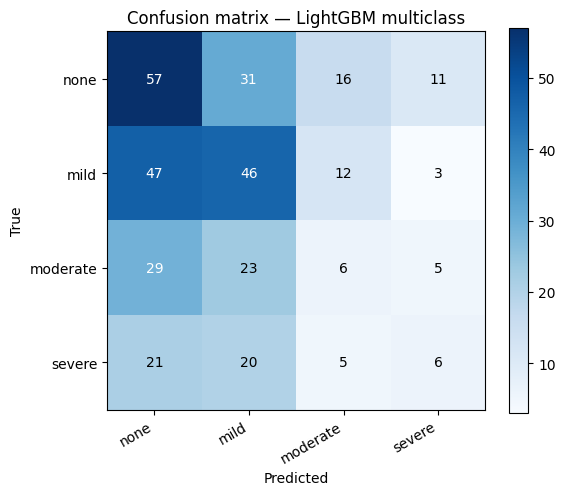


  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS
  sorted by ROC-AUC OvR


,model,roc_auc_ovr,accuracy,f1_macro
0,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
1,LightGBM multiclass,0.5183,0.3402,0.2752
2,2. FA(18) + XGBoost,0.5177,0.3225,0.2469
3,1. Raw XGBoost (no FA),0.5057,0.3077,0.2449
4,5. Dummy (most_frequent),0.5000,0.3402,0.1269
5,mord LogisticAT (raw),0.4988,0.2988,0.1954
6,mord LogisticAT (FA-18),0.4922,0.3195,0.1211
7,4. BalancedRandomForest (no FA),0.4886,0.2604,0.2061


In [28]:

# ── ordinal dataset (same 4-class split used by multiclass section) ───────────
# Xtr_mc / Xte_mc / ytr_mc / yte_mc already in scope

# mord expects integer class labels starting at 0 — already the case (0,1,2,3)

# ── 1. mord LogisticAT on raw features (needs scaling) ───────────────────────
scaler_raw = StandardScaler()
Xtr_sc = scaler_raw.fit_transform(Xtr_mc)
Xte_sc = scaler_raw.transform(Xte_mc)

ord_mord_raw = mord.LogisticAT(alpha=1.0)
ord_mord_raw.fit(Xtr_sc, ytr_mc)
ord_mord_raw_proba = ord_mord_raw.predict_proba(Xte_sc)
ord_mord_raw_preds = ord_mord_raw.predict(Xte_sc)

# ── 2. mord LogisticAT on FA(18) features ────────────────────────────────────
_fa_ord = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr_ord_fa = _fa_ord.fit_transform(Xtr_mc)
Xte_ord_fa = _fa_ord.transform(Xte_mc)

scaler_fa = StandardScaler()
Xtr_ord_fa_sc = scaler_fa.fit_transform(Xtr_ord_fa)
Xte_ord_fa_sc = scaler_fa.transform(Xte_ord_fa)

ord_mord_fa = mord.LogisticAT(alpha=1.0)
ord_mord_fa.fit(Xtr_ord_fa_sc, ytr_mc)
ord_mord_fa_proba = ord_mord_fa.predict_proba(Xte_ord_fa_sc)
ord_mord_fa_preds = ord_mord_fa.predict(Xte_ord_fa_sc)

# ── 3. LightGBM multiclass (is_unbalance handles class skew) ─────────────────
lgb_mc = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    random_state=42,
    is_unbalance=True,
    objective="multiclass",
    num_class=4,
    verbose=-1,
)
lgb_mc.fit(Xtr_mc, ytr_mc)
lgb_mc_proba = lgb_mc.predict_proba(Xte_mc)
lgb_mc_preds = lgb_mc.predict(Xte_mc)

# ── evaluate ──────────────────────────────────────────────────────────────────
ord_results = [
    evaluate_mc("mord LogisticAT (raw)",    yte_mc, ord_mord_raw_preds, ord_mord_raw_proba),
    evaluate_mc("mord LogisticAT (FA-18)",  yte_mc, ord_mord_fa_preds,  ord_mord_fa_proba),
    evaluate_mc("LightGBM multiclass",       yte_mc, lgb_mc_preds,        lgb_mc_proba),
]

# ── compare against standard multiclass results ───────────────────────────────
ord_df = pd.DataFrame(ord_results)
comparison_df = pd.concat(
    [mc_results_df[["model", "roc_auc_ovr", "accuracy", "f1_macro"]], ord_df],
    ignore_index=True,
).sort_values("roc_auc_ovr", ascending=False).reset_index(drop=True)

# ── confusion matrix for best ordinal/lgbm result ────────────────────────────
best_ord_row = ord_df.sort_values("roc_auc_ovr", ascending=False).iloc[0]
best_ord_name = best_ord_row["model"]

if best_ord_name == "mord LogisticAT (raw)":
    _best_preds = ord_mord_raw_preds
elif best_ord_name == "mord LogisticAT (FA-18)":
    _best_preds = ord_mord_fa_preds
else:
    _best_preds = lgb_mc_preds

cm_ord = confusion_matrix(yte_mc, _best_preds)
fig_ord, ax_ord = plt.subplots(figsize=(6, 5))
im_ord = ax_ord.imshow(cm_ord, cmap="Blues")
ax_ord.set_xticks(range(4)); ax_ord.set_yticks(range(4))
ax_ord.set_xticklabels(MC_NAMES, rotation=30, ha="right")
ax_ord.set_yticklabels(MC_NAMES)
ax_ord.set_xlabel("Predicted"); ax_ord.set_ylabel("True")
ax_ord.set_title(f"Confusion matrix — {best_ord_name}")
for i in range(4):
    for j in range(4):
        ax_ord.text(j, i, cm_ord[i, j], ha="center", va="center",
                    color="white" if cm_ord[i, j] > cm_ord.max() / 2 else "black")
plt.colorbar(im_ord, ax=ax_ord)
plt.tight_layout()

# ── mlflow ────────────────────────────────────────────────────────────────────
import re

def _safe_metric_key(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-\. /]", "", name).replace(" ", "_")

mlflow.end_run()
with mlflow.start_run(run_name="ordinal_mord_lgbm_comparison"):
    for row in ord_results:
        prefix = _safe_metric_key(row["model"])
        mlflow.log_metric(f"{prefix}_roc_auc_ovr", row["roc_auc_ovr"])
        mlflow.log_metric(f"{prefix}_accuracy",    row["accuracy"])
        mlflow.log_metric(f"{prefix}_f1_macro",    row["f1_macro"])
    mlflow.log_text(comparison_df.to_csv(index=False), "ordinal_mord_lgbm_vs_standard_mc.csv")
    mlflow.log_figure(fig_ord, "ordinal_best_confusion_matrix.png")

plt.show()

print("\n" + "=" * 58)
print("  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS")
print("  sorted by ROC-AUC OvR")
print("=" * 58)
display(comparison_df)


## Overall Summary — All Approaches

Unified comparison across every section of the notebook.
`roc_auc` is the standard binary ROC-AUC for binary tasks and ROC-AUC OvR (macro) for multiclass/ordinal tasks.

In [29]:

# ── helper: normalise a comparison df into (approach, model, roc_auc, accuracy, f1_macro) ──
def _tag(df, approach, auc_col="roc_auc"):
    out = df[["model", auc_col, "accuracy", "f1_macro"]].copy()
    out = out.rename(columns={auc_col: "roc_auc"})
    out.insert(0, "approach", approach)
    return out

# 1. Binary AHI≥5 — original model comparison
s1 = _tag(results_df, "Binary AHI≥5")

# 2. AHI threshold sweep — one FA(18)+XGB row per threshold
thresh_best = thresh_df[["label", "roc_auc", "accuracy", "f1_macro"]].copy()
thresh_best.insert(0, "approach", "AHI threshold sweep")
thresh_best = thresh_best.rename(columns={"label": "model"})

# 3. Binary AHI≥15
s3 = _tag(res15_df, "Binary AHI≥15")

# 4. Multiclass 4-class
s4 = _tag(mc_results_df, "Multiclass 4-class", auc_col="roc_auc_ovr")

# 5. Ordinal / mord / LightGBM (the three new models only — mc already in s4)
s5 = _tag(ord_df, "Ordinal / mord / LightGBM", auc_col="roc_auc_ovr")

overall_df = (
    pd.concat([s1, thresh_best, s3, s4, s5], ignore_index=True)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── best result per approach ─────────────────────────────────────────────────
best_per_approach = (
    overall_df.groupby("approach", sort=False)
    .apply(lambda g: g.loc[g["roc_auc"].idxmax()])
    .reset_index(drop=True)
    [["approach", "model", "roc_auc", "accuracy", "f1_macro"]]
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── log to mlflow ─────────────────────────────────────────────────────────────
mlflow.end_run()
with mlflow.start_run(run_name="overall_summary_comparison"):
    mlflow.log_text(overall_df.to_csv(index=False),       "overall_summary.csv")
    mlflow.log_text(best_per_approach.to_csv(index=False), "best_per_approach.csv")
    for _, row in best_per_approach.iterrows():
        key = re.sub(r"[^a-zA-Z0-9_]", "_", row["approach"])
        mlflow.log_metric(f"best_roc_auc_{key}", round(row["roc_auc"], 4))

# ── display ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 64)
print("  BEST MODEL PER APPROACH")
print("=" * 64)
display(
    best_per_approach.style
    .format({"roc_auc": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"})
    .background_gradient(subset=["roc_auc"], cmap="RdYlGn", vmin=0.45, vmax=0.65)
)

print("\n" + "=" * 64)
print("  ALL MODELS — RANKED BY ROC-AUC")
print("=" * 64)
display(
    overall_df.style
    .format({"roc_auc": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"})
    .background_gradient(subset=["roc_auc"], cmap="RdYlGn", vmin=0.45, vmax=0.65)
    .set_caption("Overall comparison — all approaches (sorted by ROC-AUC)")
)



  BEST MODEL PER APPROACH


,approach,model,roc_auc,accuracy,f1_macro
0,Binary AHI≥15,5. BalancedRandomForest,0.5690,0.6183,0.5293
1,AHI threshold sweep,AHI≥5,0.5400,0.5385,0.5190
2,Binary AHI≥5,3. FA(18) + XGBoost + scale_pos_weight,0.5400,0.5385,0.5190
3,Multiclass 4-class,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
4,Ordinal / mord / LightGBM,LightGBM multiclass,0.5183,0.3402,0.2752



  ALL MODELS — RANKED BY ROC-AUC


,approach,model,roc_auc,accuracy,f1_macro
0,Binary AHI≥15,5. BalancedRandomForest,0.5690,0.6183,0.5293
1,Binary AHI≥15,7. BalancedRandomForest + thresh=0.17,0.5451,0.5473,0.5376
2,Binary AHI≥15,1. Raw XGBoost,0.5451,0.6006,0.5010
3,Binary AHI≥15,2. XGBoost + scale_pos_weight,0.5410,0.6036,0.5296
4,AHI threshold sweep,AHI≥5,0.5400,0.5385,0.5190
5,Binary AHI≥5,3. FA(18) + XGBoost + scale_pos_weight,0.5400,0.5385,0.5190
6,AHI threshold sweep,AHI≥30,0.5320,0.5799,0.4624
7,Multiclass 4-class,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
8,Binary AHI≥15,6. LightGBM (is_unbalance),0.5293,0.5769,0.5123
9,Ordinal / mord / LightGBM,LightGBM multiclass,0.5183,0.3402,0.2752


steps to take maybe
1. Feature selection before FA — use only the ~6 top SHAP factors' original variables as input to FA, rather than all features. Less noise going in
2. smoteenn or smotetomek?
3. lightgbm maybe 
4. stacking ensembles 
5. cross-validate shap values